ch1 gewichteter Fit: y = 83.1985 * t + 12.9135
ch2 gewichteter Fit: y = 0.3754 * t + 2.4244
x   ungewichteter Fit: y = 84.2988 * t + 25.0614


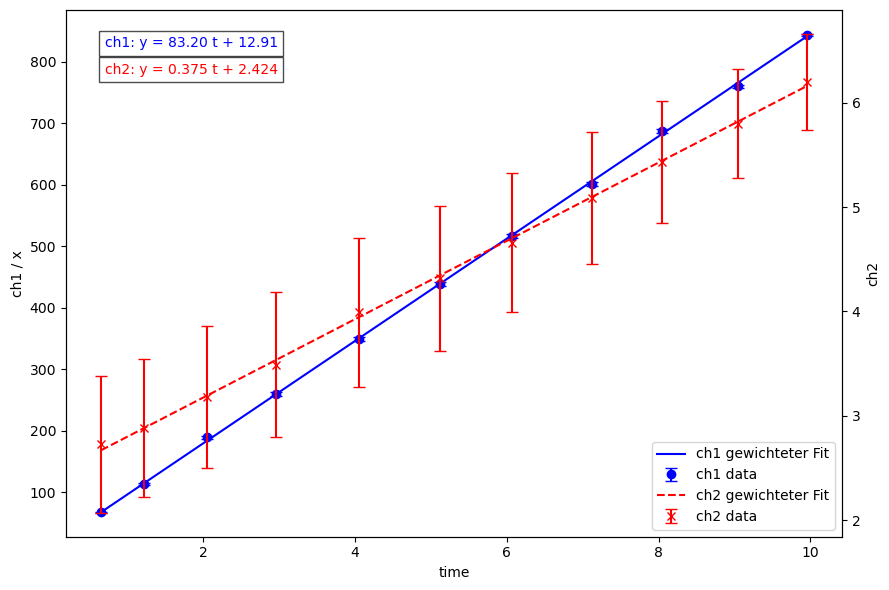

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Daten
# -----------------------------
time = np.array([
    1.219, 2.052, 2.962, 4.045, 5.116,
    6.063, 7.117, 8.047, 9.047, 9.949, 0.654
])

ch1 = np.array([
    113.25, 189, 259.3, 348.88, 438.00,
    516.86, 600.63, 687.20, 759.68, 843.00, 67.118
])

ch2 = np.array([
    28.822, 31.8, 34.9, 39.912, 43.180,
    46.596, 50.849, 54.333, 57.995, 61.988, 27.246
]) / 10

x = np.array([
    112.13, 205, 280.04, 370.02, 451.60,
    538.65, 624.07, 703.55, 783.22, 866.33, 84.644
])

# ---------------------------------------------------------
# HIER SPÄTER den fehlenden Punkt bei t ~ 0.6 ergänzen
# Dann müssen time, ch1, ch2, x und mask dieselbe Länge haben.
# ---------------------------------------------------------

# 1 = hier existiert eine gemessene Standardabweichung, 0 = nicht vorhanden
mask_std = np.array([0, 1, 0, 0, 0, 1, 0, 0, 0, 1,1], dtype=bool)
# Falls du den fehlenden Punkt ergänzt hast, nimm z.B.:
# mask_std = np.array([0,1,0,0,0,1,0,0,0,1,1], dtype=bool)

# ---------------------------------------------------------
# Trage hier NUR die wirklich gemessenen Standardabweichungen ein
# und zwar in derselben Reihenfolge wie die 1en in mask_std.
# Beispielwerte bitte durch deine echten Werte ersetzen.
# ---------------------------------------------------------
std_ch1_known = np.array([
    1.3,   # Standardabweichung für den 2. markierten Punkt
    2.66,   # Standardabweichung für den 6. markierten Punkt
    3.22,1.17    # Standardabweichung für den 10. markierten Punkt
])

std_ch2_known = np.array([
    0.617,  # für denselben Punkt wie oben
    0.46762,
    0.63683, 
    0.753
])

# -----------------------------
# Hilfsfunktion:
# relative Fehler aus bekannten Punkten bestimmen,
# dann linear auf alle Punkte extrapolieren/interpolieren
# -----------------------------
def extrapolate_sigma_from_relative_error(time, values, mask, sigma_known):
    t_known = time[mask]
    y_known = values[mask]

    # relative Fehler an den bekannten Stellen
    rel_err_known = sigma_known / y_known

    # linearer Fit des relativen Fehlers über der Zeit
    m_rel, b_rel = np.polyfit(t_known, rel_err_known, 1)

    rel_err_all = m_rel * time + b_rel

    # Sicherheit: negative Fehler vermeiden
    rel_err_all = np.clip(rel_err_all, 1e-12, None)

    sigma_all = rel_err_all * values
    return sigma_all, rel_err_all, m_rel, b_rel

# Geschätzte Fehler für alle Punkte
sigma_ch1, relerr_ch1, mrel1, brel1 = extrapolate_sigma_from_relative_error(
    time, ch1, mask_std, std_ch1_known
)

sigma_ch2, relerr_ch2, mrel2, brel2 = extrapolate_sigma_from_relative_error(
    time, ch2, mask_std, std_ch2_known
)

# -----------------------------
# Fehlergewichtete lineare Fits
# w = 1/sigma
# -----------------------------
m1, b1 = np.polyfit(time, ch1, 1, w=1/sigma_ch1)
m2, b2 = np.polyfit(time, ch2, 1, w=1/sigma_ch2)
m3, b3 = np.polyfit(time, x, 1)   # für x weiterhin ungewichtet

print(f"ch1 gewichteter Fit: y = {m1:.4f} * t + {b1:.4f}")
print(f"ch2 gewichteter Fit: y = {m2:.4f} * t + {b2:.4f}")
print(f"x   ungewichteter Fit: y = {m3:.4f} * t + {b3:.4f}")

# Fit-Strings
fit_text_ch1 = f"ch1: y = {m1:.2f} t + {b1:.2f}"
fit_text_ch2 = f"ch2: y = {m2:.3f} t + {b2:.3f}"

t_fit = np.linspace(np.min(time), np.max(time), 300)

# -----------------------------
# Plot
# -----------------------------
fig, ax1 = plt.subplots(figsize=(9, 6))

# ch1 mit Fehlerbalken
ax1.errorbar(
    time, ch1, yerr=sigma_ch1,
    fmt='o', capsize=4, label='ch1 data', color ='blue'
)
ax1.plot(
    t_fit, m1 * t_fit + b1,
    label='ch1 gewichteter Fit', color ='blue'
)

# x
#ax1.scatter(time, x, label='x data')
#ax1.plot(
#    t_fit, m3 * t_fit + b3,
#    label='x Fit'
#)

ax1.set_xlabel("time")
ax1.set_ylabel("ch1 / x")

# ch2 auf zweiter Achse
ax2 = ax1.twinx()
ax2.errorbar(
    time, ch2, yerr=sigma_ch2,
    fmt='x', capsize=4, label='ch2 data', color ='red'
)
ax2.plot(
    t_fit, m2 * t_fit + b2,
    linestyle='--', label='ch2 gewichteter Fit', color ='red'
)
ax2.set_ylabel("ch2")

ax1.text(
    0.05, 0.95, fit_text_ch1,
    transform=ax1.transAxes,
    fontsize=10,
    verticalalignment='top',
    color='blue',
    bbox=dict(facecolor='white', alpha=0.7)
)

ax2.text(
    0.05, 0.90, fit_text_ch2,
    transform=ax2.transAxes,
    fontsize=10,
    verticalalignment='top',
    color='red',
    bbox=dict(facecolor='white', alpha=0.7)
)

# gemeinsame Legende
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

#ax1.grid()
plt.tight_layout()
plt.show()

Anzahl der Channels: 1028


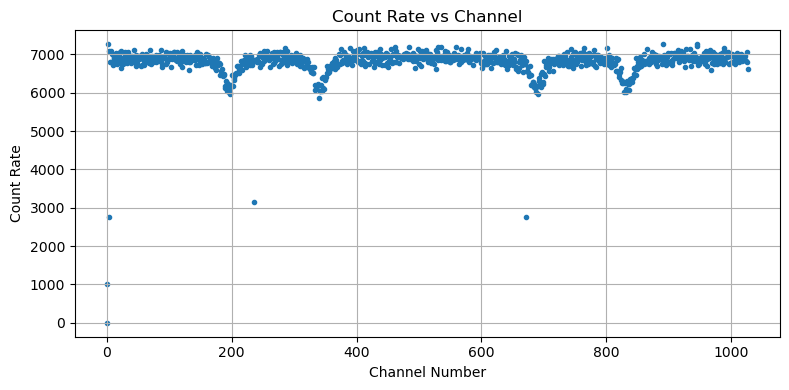

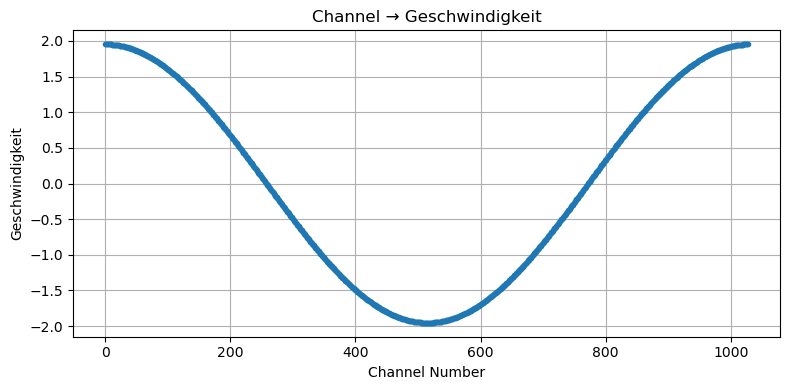

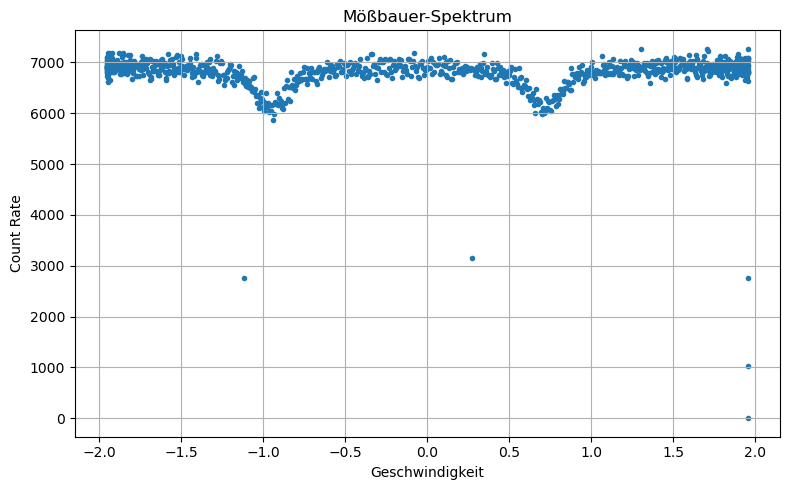

In [16]:
# ganze schwingung

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --------------------------------------------------
# Beispiel: lineare Fits aus der vorherigen Aufgabe
# Die Werte m1, b1, m2, b2 kommen aus deinem Fit
# --------------------------------------------------
# Beispielnamen:
m_velo = m1     # Steigung von fit_ch1
b_velo = b1
m_error = m2    # Steigung von fit_ch2
b_error = b2

fit_ch1 = lambda t: m_velo * t + b_velo
fit_ch2 = lambda t: m_error * t + b_error

def plot_moessbauer_spectrum_full(datei, velocity_max, alpha=1):

    data = pd.read_csv(datei, sep=r"\s+|,|;", header=None, engine="python")

    counts = data.to_numpy().flatten()

    n_max = len(counts)
    print(f"Anzahl der Channels: {n_max}")

    # Reihenfolge umdrehen
    #counts = counts[::-1] #daten laufen von - zu plus, nicht, wie angenommen, von + zu -

    # Channel-Indizes
    n = np.arange(n_max)

    # ----------------------------------
    # NEU: Plot Count Rate vs Channel
    # ----------------------------------
    plt.figure(figsize=(8, 4))
    plt.scatter(n, counts, marker='.', linestyle='-')
    plt.xlabel("Channel Number")
    plt.ylabel("Count Rate")
    plt.title("Count Rate vs Channel")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ----------------------------------
    # Geschwindigkeiten berechnen
    # ----------------------------------
    velocities = alpha * velocity_max * (
        np.cos(2 * np.pi * (n / n_max))
        + (m_error / m_velo) * np.sin(2 * np.pi * n / n_max)
    )

    plt.figure(figsize=(8, 4))
    plt.plot(n, velocities, marker='.', linestyle='-')
    plt.xlabel("Channel Number")
    plt.ylabel("Geschwindigkeit")
    plt.title("Channel → Geschwindigkeit")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ----------------------------------
    # Plot Count Rate vs Geschwindigkeit
    # ----------------------------------
    plt.figure(figsize=(8, 5))
    plt.scatter(velocities, counts, marker='.', linestyle='-')
    plt.xlabel("Geschwindigkeit")
    plt.ylabel("Count Rate")
    plt.title("Mößbauer-Spektrum")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return velocities, counts

velocities, counts = plot_moessbauer_spectrum_full("Daten/AlphaIron_AbsorptionSpectrum.dat", velocity_max=1.954)

Anzahl der Channels: 515


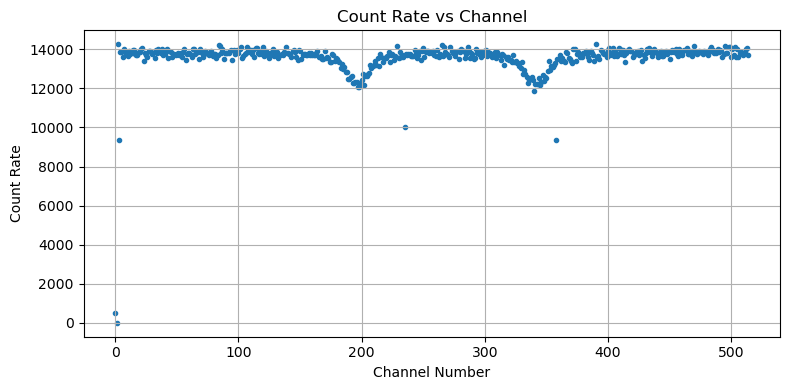

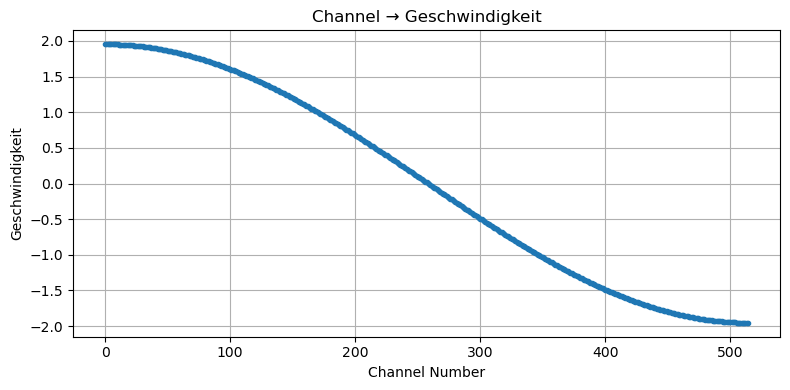

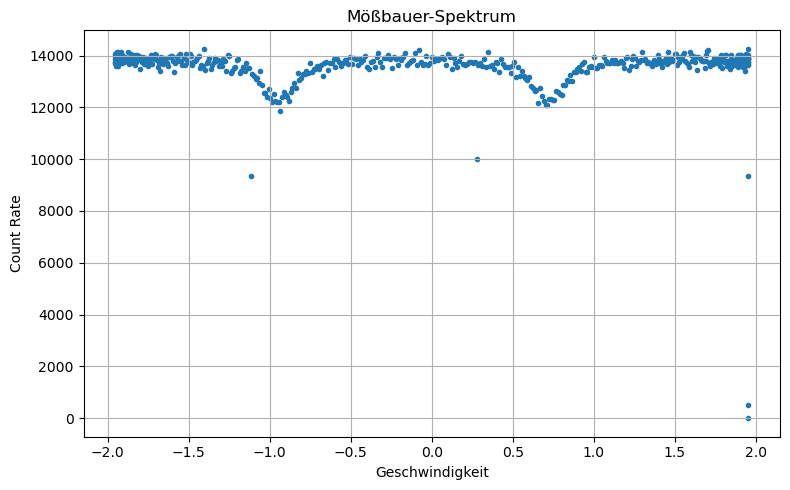

In [17]:
# halbe schwingung

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --------------------------------------------------
# Beispiel: lineare Fits aus der vorherigen Aufgabe
# Die Werte m1, b1, m2, b2 kommen aus deinem Fit
# --------------------------------------------------
# Beispielnamen:
m_velo = m1     # Steigung von fit_ch1
b_velo = b1
m_error = m2    # Steigung von fit_ch2
b_error = b2

fit_ch1 = lambda t: m_velo * t + b_velo
fit_ch2 = lambda t: m_error * t + b_error

def plot_moessbauer_spectrum(datei, velocity_max, alpha=1):

    data = pd.read_csv(datei, sep=r"\s+|,|;", header=None, engine="python")

    counts = data.to_numpy().flatten()

    n_max = len(counts)
    print(f"Anzahl der Channels: {n_max}")

    # Reihenfolge umdrehen
    #counts = counts[::-1] #daten laufen von - zu plus, nicht, wie angenommen, von + zu -

    # Channel-Indizes
    n = np.arange(n_max)

    # ----------------------------------
    # NEU: Plot Count Rate vs Channel
    # ----------------------------------
    plt.figure(figsize=(8, 4))
    plt.scatter(n, counts, marker='.', linestyle='-')
    plt.xlabel("Channel Number")
    plt.ylabel("Count Rate")
    plt.title("Count Rate vs Channel")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ----------------------------------
    # Geschwindigkeiten berechnen
    # ----------------------------------
    velocities = alpha * velocity_max * (
        np.cos( np.pi * (n / n_max))
        + (m_error / m_velo) * np.sin( np.pi * n / n_max)
    )

    plt.figure(figsize=(8, 4))
    plt.plot(n, velocities, marker='.', linestyle='-')
    plt.xlabel("Channel Number")
    plt.ylabel("Geschwindigkeit")
    plt.title("Channel → Geschwindigkeit")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ----------------------------------
    # Plot Count Rate vs Geschwindigkeit
    # ----------------------------------
    plt.figure(figsize=(8, 5))
    plt.scatter(velocities, counts, marker='.', linestyle='-')
    plt.xlabel("Geschwindigkeit")
    plt.ylabel("Count Rate")
    plt.title("Mößbauer-Spektrum")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return velocities, counts

velocities, counts = plot_moessbauer_spectrum("Daten/AlphaIron_AbsorptionSpectrum_Folded_511.txt", velocity_max=1.954)

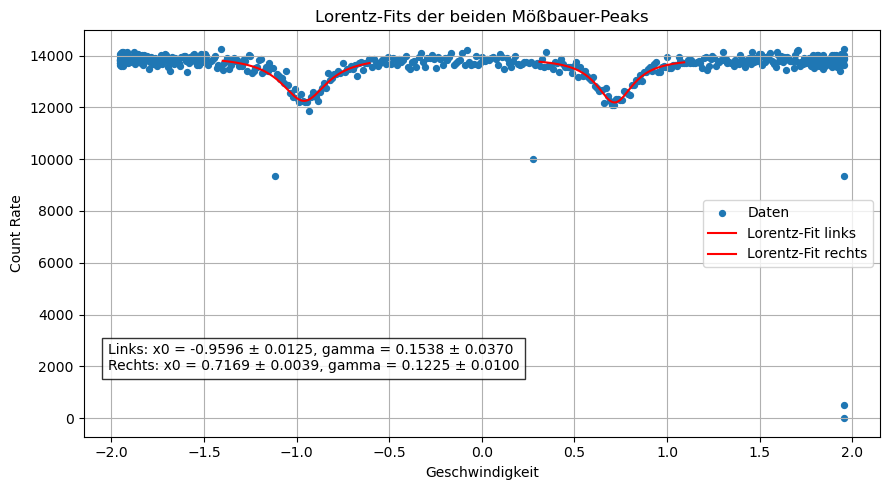

Linker Peak: {'y0': np.float64(13986.228813775018), 'A': np.float64(1737.003711069078), 'x0': np.float64(-0.9595819850335118), 'gamma': np.float64(0.15378372919636468)}
Rechter Peak: {'y0': np.float64(13903.094128541636), 'A': np.float64(1714.3165393158642), 'x0': np.float64(0.7168860835493026), 'gamma': np.float64(0.12246599590260532)}


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def lorentz_dip(x, y0, A, x0, gamma):
    """
    Lorentz-Dip:
    y0    : Untergrund
    A     : Tiefe des Dips (>0)
    x0    : Zentrum
    gamma : Halbwertsbreite
    """
    return y0 - A * (gamma**2 / ((x - x0)**2 + gamma**2))


def fit_lorentz_two_peaks(
    velocities,
    counts,
    center_left=-1.0,
    center_right=0.6,
    window_left=0.4,
    window_right=0.4,
    plot=True
):
    velocities = np.asarray(velocities)
    counts = np.asarray(counts)

    # Nach Geschwindigkeit sortieren
    order = np.argsort(velocities)
    v = velocities[order]
    c = counts[order]

    # Fenster um die erwarteten Peakpositionen
    mask_left = (v >= center_left - window_left) & (v <= center_left + window_left)
    mask_right = (v >= center_right - window_right) & (v <= center_right + window_right)

    vL, cL = v[mask_left], c[mask_left]
    vR, cR = v[mask_right], c[mask_right]

    if len(vL) < 5:
        raise ValueError("Zu wenige Punkte im linken Fitfenster.")
    if len(vR) < 5:
        raise ValueError("Zu wenige Punkte im rechten Fitfenster.")

    # Startwerte links
    y0L = np.max(cL)
    x0L = vL[np.argmin(cL)]
    AL = y0L - np.min(cL)
    gammaL = 0.1

    # Startwerte rechts
    y0R = np.max(cR)
    x0R = vR[np.argmin(cR)]
    AR = y0R - np.min(cR)
    gammaR = 0.1

    p0L = [y0L, AL, x0L, gammaL]
    p0R = [y0R, AR, x0R, gammaR]

    # Schranken: A > 0, gamma > 0, x0 im jeweiligen Fenster
    bounds_left = (
        [-np.inf, 0, center_left - window_left, 1e-6],
        [ np.inf, np.inf, center_left + window_left, np.inf]
    )
    bounds_right = (
        [-np.inf, 0, center_right - window_right, 1e-6],
        [ np.inf, np.inf, center_right + window_right, np.inf]
    )

    poptL, pcovL = curve_fit(
        lorentz_dip, vL, cL, p0=p0L, bounds=bounds_left, maxfev=20000
    )
    poptR, pcovR = curve_fit(
        lorentz_dip, vR, cR, p0=p0R, bounds=bounds_right, maxfev=20000
    )

    perrL = np.sqrt(np.diag(pcovL))
    perrR = np.sqrt(np.diag(pcovR))

    if plot:
        vL_dense = np.linspace(vL.min(), vL.max(), 400)
        vR_dense = np.linspace(vR.min(), vR.max(), 400)

        plt.figure(figsize=(9, 5))
        plt.scatter(v, c, s=18, label="Daten")
        plt.plot(vL_dense, lorentz_dip(vL_dense, *poptL), label="Lorentz-Fit links", color='red')
        plt.plot(vR_dense, lorentz_dip(vR_dense, *poptR), label="Lorentz-Fit rechts", color='red')

        #plt.axvline(center_left, linestyle="--", alpha=0.5)
        #plt.axvline(center_right, linestyle="--", alpha=0.5)

        plt.xlabel("Geschwindigkeit")
        plt.ylabel("Count Rate")
        plt.title("Lorentz-Fits der beiden Mößbauer-Peaks")
        plt.grid(True)
        plt.legend()

        text = (
            f"Links: x0 = {poptL[2]:.4f} ± {perrL[2]:.4f}, gamma = {poptL[3]:.4f} ± {perrL[3]:.4f}\n"
            f"Rechts: x0 = {poptR[2]:.4f} ± {perrR[2]:.4f}, gamma = {poptR[3]:.4f} ± {perrR[3]:.4f}"
        )
        plt.text(
            0.03, 0.23, text,
            transform=plt.gca().transAxes,
            va="top",
            bbox=dict(facecolor="white", alpha=0.8)
        )

        plt.tight_layout()
        plt.show()

    return {
        "left": {
            "params": {"y0": poptL[0], "A": poptL[1], "x0": poptL[2], "gamma": poptL[3]},
            "errors": {"y0": perrL[0], "A": perrL[1], "x0": perrL[2], "gamma": perrL[3]},
            "cov": pcovL,
        },
        "right": {
            "params": {"y0": poptR[0], "A": poptR[1], "x0": poptR[2], "gamma": poptR[3]},
            "errors": {"y0": perrR[0], "A": perrR[1], "x0": perrR[2], "gamma": perrR[3]},
            "cov": pcovR,
        }
    }

fit_results = fit_lorentz_two_peaks(
    velocities,
    counts,
    center_left=-1.0,
    center_right=0.7,
    window_left=0.4,
    window_right=0.4
)

print("Linker Peak:", fit_results["left"]["params"])
print("Rechter Peak:", fit_results["right"]["params"])

In [19]:
alpha = 0.5722
-0.9596-0.7169

-1.6764999999999999

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit


# ----------------------------------
# Lorentz-Dip
# ----------------------------------
def lorentz_dip(x, y0, A, x0, gamma):
    return y0 - A * (gamma**2 / ((x - x0)**2 + gamma**2))


# ----------------------------------
# Ausreißer entfernen
# Wenn ein Punkt zu stark von beiden Nachbarn abweicht,
# wird er durch den Mittelwert der Nachbarn ersetzt.
# threshold = 0.05 entspricht 5 %
# ----------------------------------
def remove_outliers_percent(counts, threshold=0.05):
    counts_filtered = counts.astype(float).copy()

    for i in range(1, len(counts_filtered) - 1):
        left = counts_filtered[i - 1]
        current = counts_filtered[i]
        right = counts_filtered[i + 1]

        # Schutz gegen Division durch 0
        if left == 0 or right == 0:
            continue

        rel_diff_left = abs(current - left) / abs(left)
        rel_diff_right = abs(current - right) / abs(right)

        # Nur dann ersetzen, wenn der Punkt zu BEIDEN Nachbarn
        # um mehr als threshold abweicht
        if rel_diff_left > threshold and rel_diff_right > threshold:
            counts_filtered[i] = 0.5 * (left + right)

    return counts_filtered


# ----------------------------------
# Datei einlesen und Geschwindigkeiten berechnen
# ----------------------------------
def load_moessbauer_data(datei, velocity_max, alpha=1, remove_outliers=True, threshold=0.05):
    data = pd.read_csv(datei, sep=r"\s+|,|;", header=None, engine="python")
    counts = data.to_numpy().flatten()[::-1].astype(float)

    if remove_outliers:
        counts = remove_outliers_percent(counts, threshold=threshold)

    n_max = len(counts)
    n = np.arange(n_max)

    #alpha = 1 / 0.5722
    velocities = alpha * velocity_max * (
        np.cos(np.pi * (n / (n_max - 1)))
        + (m_error / m_velo) * np.sin(np.pi * (n / (n_max - 1)))
    )

    order = np.argsort(velocities)
    velocities = velocities[order]
    counts = counts[order]

    return velocities, counts


# ----------------------------------
# Allgemeine Multi-Fit-Funktion
# ----------------------------------
def fit_lorentz_peaks(datei, velocity_max, n_fits, centers, windows, alpha=1, plot=True,
                      remove_outliers=True, threshold=0.05):
    """
    Führt 1 bis 6 Lorentz-Fits auf einem Mößbauer-Spektrum aus.
    """

    if not (1 <= n_fits <= 6):
        raise ValueError("n_fits muss zwischen 1 und 6 liegen.")

    if len(centers) != n_fits:
        raise ValueError("centers muss genau n_fits Einträge haben.")

    if len(windows) != n_fits:
        raise ValueError("windows muss genau n_fits Einträge haben.")

    velocities, counts = load_moessbauer_data(
        datei,
        velocity_max,
        alpha=alpha,
        remove_outliers=remove_outliers,
        threshold=threshold
    )

    results = []

    for i in range(n_fits):
        center = centers[i]
        window = windows[i]

        mask = (velocities >= center - window) & (velocities <= center + window)
        v_fit = velocities[mask]
        c_fit = counts[mask]

        if len(v_fit) < 5:
            raise ValueError(f"Zu wenige Punkte für Fit {i+1} im Fenster um {center}.")

        y0_guess = np.max(c_fit)
        x0_guess = v_fit[np.argmin(c_fit)]
        A_guess = y0_guess - np.min(c_fit)
        gamma_guess = max((v_fit.max() - v_fit.min()) / 10, 1e-3)

        p0 = [y0_guess, A_guess, x0_guess, gamma_guess]

        bounds = (
            [-np.inf, 0, center - window, 1e-6],
            [ np.inf, np.inf, center + window, np.inf]
        )

        popt, pcov = curve_fit(
            lorentz_dip, v_fit, c_fit, p0=p0, bounds=bounds, maxfev=20000
        )
        perr = np.sqrt(np.diag(pcov))

        results.append({
            "fit_index": i + 1,
            "fit_range": (center - window, center + window),
            "params": {
                "y0": popt[0],
                "A": popt[1],
                "x0": popt[2],
                "gamma": popt[3],
            },
            "errors": {
                "y0": perr[0],
                "A": perr[1],
                "x0": perr[2],
                "gamma": perr[3],
            },
            "cov": pcov
        })

    if plot:
        plt.figure(figsize=(10, 6))
        plt.scatter(velocities, counts, s=14, label="Daten")

        for res in results:
            x_min, x_max = res["fit_range"]
            v_dense = np.linspace(x_min, x_max, 400)
            p = res["params"]

            plt.plot(
                v_dense,
                lorentz_dip(v_dense, p["y0"], p["A"], p["x0"], p["gamma"]),
                label=f'Fit {res["fit_index"]}',
                color='red'
            )

            #plt.axvspan(x_min, x_max, alpha=0.12)

        plt.xlabel("Geschwindigkeit")
        plt.ylabel("Count Rate")
        plt.title("Mößbauer-Spektrum mit Lorentz-Fits")
        plt.grid(True)
        plt.legend()

        text = ""
        for res in results:
            p = res["params"]
            e = res["errors"]
            text += (
                f'Fit {res["fit_index"]}: '
                f'x0 = {p["x0"]:.4f} ± {e["x0"]:.4f}, '
                f'gamma = {p["gamma"]:.4f} ± {e["gamma"]:.4f}\n'
            )

        plt.text(
            0.02, 0.28, text,
            transform=plt.gca().transAxes,
            va="top",
            bbox=dict(facecolor="white", alpha=0.8)
        )

        plt.tight_layout()
        plt.show()

    return velocities, counts, results

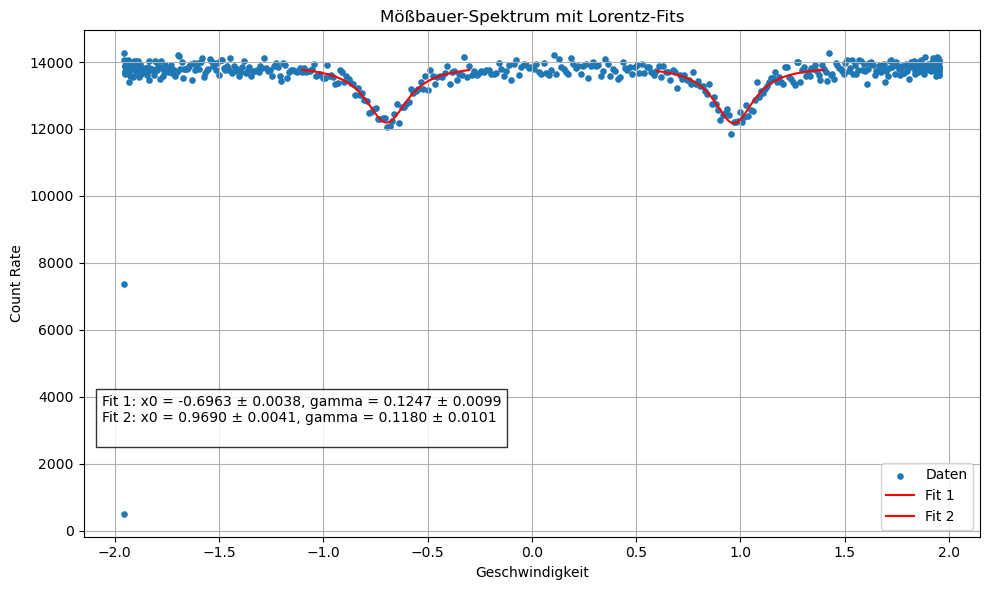

In [22]:
velocities, counts, results = fit_lorentz_peaks(
    datei="Daten/AlphaIron_AbsorptionSpectrum_Folded_511.txt",
    velocity_max=1.954,
    n_fits=2,
    centers=[-0.7, 1],
    windows=[0.4, 0.4]
)